In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
import joblib

RANDOM_STATE = 42

In [9]:
import pandas as pd

csv_name = next(name for name in uploaded if name.lower().endswith(".csv"))

df = pd.read_csv(csv_name)

print("Loaded:", csv_name, "| shape:", df.shape)
df.head()
from google.colab import files
uploaded = files.upload()   # pick sample_-_superstore.csv

csv_name = next(name for name in uploaded if name.lower().endswith(".csv"))
df = pd.read_csv(csv_name)
print("Loaded:", csv_name, "| shape:", df.shape)
df.head()

Loaded: sample_-_superstore (3).csv | shape: (10194, 21)


Saving sample_-_superstore.csv to sample_-_superstore (4).csv
Saving sample_-_superstore.xls to sample_-_superstore (4).xls
Loaded: sample_-_superstore (4).csv | shape: (10194, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [10]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Profitable orders (Profit > 0):", round((df['Profit'] > 0).mean(), 3))
df.describe(include='all').T

Shape: (10194, 21)
Missing values: 0
Profitable orders (Profit > 0): 0.807


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,10194.0,NaN,NaN,NaN,5097.5,2942.898656,1.0,2549.25,5097.5,7645.75,10194.0
Order ID,10194,5111,US-2026-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,10194,1242,09/05/2025,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,10194,1338,12/16/2024,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,10194,4,Standard Class,6120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,10194,804,WB-21850,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,10194,800,William Brown,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,10194,3,Consumer,5281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country/Region,10194,2,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,10194,542,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  format="%m/%d/%Y")
df["ship_days"]     = (df["Ship Date"] - df["Order Date"]).dt.days
df["order_month"]   = df["Order Date"].dt.month
df["order_quarter"] = df["Order Date"].dt.quarter

df["profitable"] = (df["Profit"] > 0).astype(int)   # 1 = profit, 0 = loss

NUMERIC_FEATURES = ["Sales", "Quantity", "Discount", "ship_days",
                    "order_month", "order_quarter"]
CATEGORICAL_FEATURES = ["Ship Mode", "Segment", "Region",
                        "Category", "Sub-Category"]

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["profitable"]
print("Features:", X.shape[1], "| Rows:", X.shape[0])

Features: 11 | Rows: 10194


In [12]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

model = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1,
)

pipe = Pipeline([("prep", preprocessor), ("model", model)])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
pipe.fit(X_train, y_train)
print("Trained on", len(X_train), "rows.")

Trained on 8155 rows.


In [14]:
y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(f"Baseline (always 'profitable'): {y_test.mean():.3f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1 score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")
print("\nClassification report (0 = LOSS, 1 = PROFIT):")
print(classification_report(y_test, y_pred, target_names=["loss", "profit"]))

cv = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc", n_jobs=-1)
print(f"5-fold CV ROC-AUC: {cv.mean():.3f} (+/- {cv.std():.3f})")

Baseline (always 'profitable'): 0.807
Accuracy : 0.933
Precision: 0.961
Recall   : 0.956
F1 score : 0.959
ROC-AUC  : 0.978

Classification report (0 = LOSS, 1 = PROFIT):
              precision    recall  f1-score   support

        loss       0.82      0.84      0.83       393
      profit       0.96      0.96      0.96      1646

    accuracy                           0.93      2039
   macro avg       0.89      0.90      0.89      2039
weighted avg       0.93      0.93      0.93      2039

5-fold CV ROC-AUC: 0.980 (+/- 0.003)


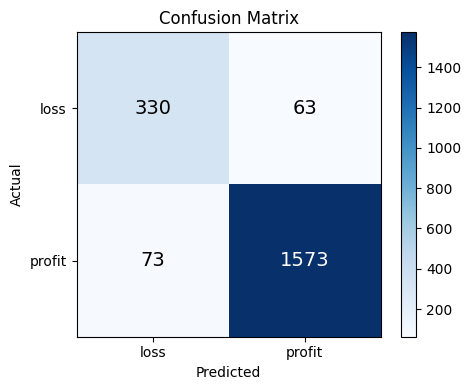

In [15]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["loss", "profit"]); ax.set_yticklabels(["loss", "profit"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.colorbar(im); plt.tight_layout(); plt.show()

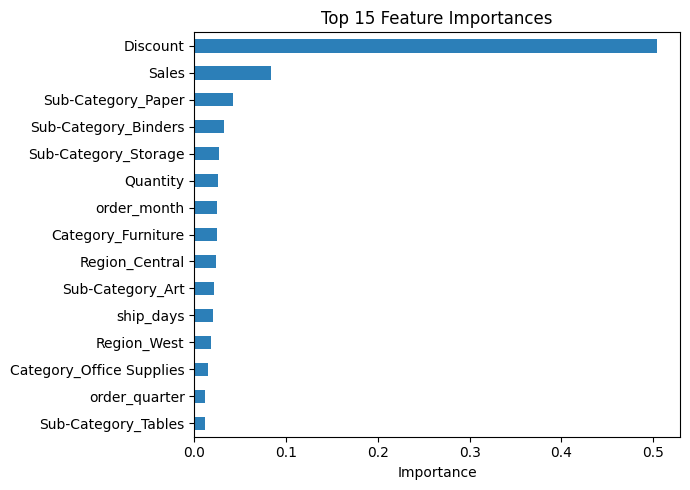

,0
Discount,0.5039
Sales,0.0834
Sub-Category_Paper,0.0422
Sub-Category_Binders,0.0321
Sub-Category_Storage,0.0265
Quantity,0.0256
order_month,0.0249
Category_Furniture,0.0246


In [16]:
ohe = pipe.named_steps["prep"].named_transformers_["cat"]
feat_names = NUMERIC_FEATURES + list(ohe.get_feature_names_out(CATEGORICAL_FEATURES))
importances = pipe.named_steps["model"].feature_importances_
top = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 5))
top[::-1].plot.barh(color="#2c7fb8")
plt.title("Top 15 Feature Importances"); plt.xlabel("Importance")
plt.tight_layout(); plt.show()
top.head(8).round(4)

In [18]:
joblib.dump(pipe, "superstore_profit_model.joblib")
files.download("superstore_profit_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
new_order = pd.DataFrame([{
    "Sales": 272.7, "Quantity": 3, "Discount": 0.8, "ship_days": 4,
    "order_month": 1, "order_quarter": 1, "Ship Mode": "Standard Class",
    "Segment": "Home Office", "Region": "Central",
    "Category": "Office Supplies", "Sub-Category": "Storage",
}])

prob = pipe.predict_proba(new_order)[0, 1]
label = "PROFIT" if pipe.predict(new_order)[0] == 1 else "LOSS"
print(f"Prediction: {label}  |  profit probability: {prob:.3f}")

Prediction: LOSS  |  profit probability: 0.005
